# KPIs

## Librerias

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt

## Carga de datos

In [5]:
data_path = "../Data/Silver_BANK_marketing_020226.csv"
df = pd.read_csv(data_path, sep=",", encoding="utf-8")


In [6]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,0,2343.0,1,0,undefined_contact_type,5,may,1042,1,-1,0,new_marketing_client,1
1,2,56,admin.,married,secondary,0,45.0,0,0,undefined_contact_type,5,may,1467,1,-1,0,new_marketing_client,1
2,3,41,technician,married,secondary,0,1270.0,1,0,undefined_contact_type,5,may,1389,1,-1,0,new_marketing_client,1
3,4,55,services,married,secondary,0,2476.0,1,0,undefined_contact_type,5,may,579,1,-1,0,new_marketing_client,1
4,5,54,admin.,married,tertiary,0,184.0,0,0,undefined_contact_type,5,may,673,2,-1,0,new_marketing_client,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11150 entries, 0 to 11149
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         11150 non-null  int64  
 1   age        11150 non-null  int64  
 2   job        11150 non-null  object 
 3   marital    11150 non-null  object 
 4   education  11150 non-null  object 
 5   default    11150 non-null  int64  
 6   balance    11150 non-null  float64
 7   housing    11150 non-null  int64  
 8   loan       11150 non-null  int64  
 9   contact    11150 non-null  object 
 10  day        11150 non-null  int64  
 11  month      11150 non-null  object 
 12  duration   11150 non-null  int64  
 13  campaign   11150 non-null  int64  
 14  pdays      11150 non-null  int64  
 15  previous   11150 non-null  int64  
 16  poutcome   11150 non-null  object 
 17  deposit    11150 non-null  int64  
dtypes: float64(1), int64(11), object(6)
memory usage: 1.5+ MB


## Cálculo de KPIs

### 1. Porcentaje de Conversión a Depósito

In [8]:
# total de clientes contactados
total_clients = df.shape[0]

# número de clientes que suscribieron depósito
total_deposits = df['deposit'].sum()

# porcentaje de conversión
conversion = (total_deposits / total_clients) * 100

conversion

np.float64(47.38116591928251)

In [9]:
#distribución de conversiones por mes
conversion_month = (
    df
    .groupby("month")
    .agg(
        total_clients=("deposit", "count"),
        conversions=("deposit", "sum"),
        cr=("deposit", lambda x: (x.mean() * 100).round(2))
    )
    .reset_index()
)

conversion_month

,month,total_clients,conversions,cr
0,apr,923,577,62.51
1,aug,1517,687,45.29
2,dec,109,99,90.83
3,feb,775,441,56.90
4,jan,344,142,41.28
5,jul,1510,626,41.46
6,jun,1221,546,44.72
7,mar,275,247,89.82
8,may,2823,924,32.73
9,nov,942,402,42.68


In [10]:
cr_distribution = conversion_month["cr"].agg(
    min_cr="min",
    q1_cr=lambda x: x.quantile(0.25),
    median_cr="median",
    q3_cr=lambda x: x.quantile(0.75),
    max_cr="max"
)

cr_distribution_pct = (cr_distribution).round(2)


In [13]:
# estadísticas de la distribución de CR para definir valores normales 
summary_table = (
    cr_distribution_pct
    .rename({
        "min_cr": "Min CR (%)",
        "q1_cr": "Q1 CR (%)",
        "median_cr": "Median CR (%)",
        "q3_cr": "Q3 CR (%)",
        "max_cr": "Max CR (%)"
    })
    .to_frame(name="Value")
)

summary_table

,Value
Min CR (%),32.73
Q1 CR (%),42.38
Median CR (%),51.10
Q3 CR (%),82.88
Max CR (%),90.83


### 2. Promedio de Duración de Llamadas de Suscriptores

In [16]:
# filtrar solo los clientes que suscribieron
subscribers = df[df['deposit'] == 1]

# suma de duración de llamadas
sum_duration = subscribers['duration'].sum()

# número de suscriptores
num_subscribers = subscribers.shape[0]

# promedio
avg_duration = sum_duration / num_subscribers

# conversión a minutos y segundos
minutes = int(avg_duration // 60)
seconds = int(avg_duration % 60)

avg_duration_f = (f"{minutes} min {seconds} s")

In [17]:
avg_duration_f


'8 min 57 s'

### 3. Porcentaje de Llamadas a Teléfono o Móvil

In [18]:
# total de contactos durante la campaña 
total_contacts = df['campaign'].sum()

# llamadas realizadas por teléfono o móvil
total_calls = df.loc[df['contact'].isin(['telephone', 'cellular']), 'campaign'].sum()

# porcentaje
pct_calls = (total_calls / total_contacts) * 100

pct_calls

np.float64(76.9791629436363)

### 4. Promedio de Contactos previos de Suscriptores

In [19]:
# filtrar solo suscriptores
subscribers = df[df['deposit'] == 1]

# promedio de contactos previos
avg_prev_contacts = subscribers['previous'].mean()

avg_prev_contacts

np.float64(1.1707363240583002)

### 5. Mes con Mayor Tasa de Conversión

In [20]:
"""
El tamaño mínimo de la muestra es de aproximadamente 384 clientes
para garantizar que la estimación de CR tenga un error de no más de ±5 puntos porcentuales
con un nivel de confianza del 95 %.

Según Cochran’s Sample Size Formula.
"""

MIN_N = 384

#encuentra el CR máximo entre los meses con volumen suficiente
max_cr_valid = (
    conversion_month
    .loc[conversion_month["total_clients"] >= MIN_N, "cr"]
    .max()
)

In [21]:
def highlight_best_month(row):
    if (row["total_clients"] >= MIN_N) and (row["cr"] == max_cr_valid):
        return ["background-color: #6fdc8c; color: black; font-weight: 600;"] * len(row)
    else:
        return [""] * len(row)


In [22]:
(
    conversion_month
    .style
    .apply(highlight_best_month, axis=1)
    .format({"cr": "{:.2f}%"})
)

,month,total_clients,conversions,cr
0,apr,923,577,62.51%
1,aug,1517,687,45.29%
2,dec,109,99,90.83%
3,feb,775,441,56.90%
4,jan,344,142,41.28%
5,jul,1510,626,41.46%
6,jun,1221,546,44.72%
7,mar,275,247,89.82%
8,may,2823,924,32.73%
9,nov,942,402,42.68%


In [23]:
valid = conversion_month[conversion_month["total_clients"] >= MIN_N].copy()

top_row = valid.loc[valid["cr"].idxmax()]
top_month = top_row["month"]

top_month 

'oct'

In [24]:
orden_meses = ["jan", "feb", "mar", "apr", "may", "jun",
               "jul", "aug", "sep", "oct", "nov", "dec"]

In [25]:

conversion_month["month"] = pd.Categorical(conversion_month["month"], categories=orden_meses, ordered=True)
conversion_month = conversion_month.sort_values("month")

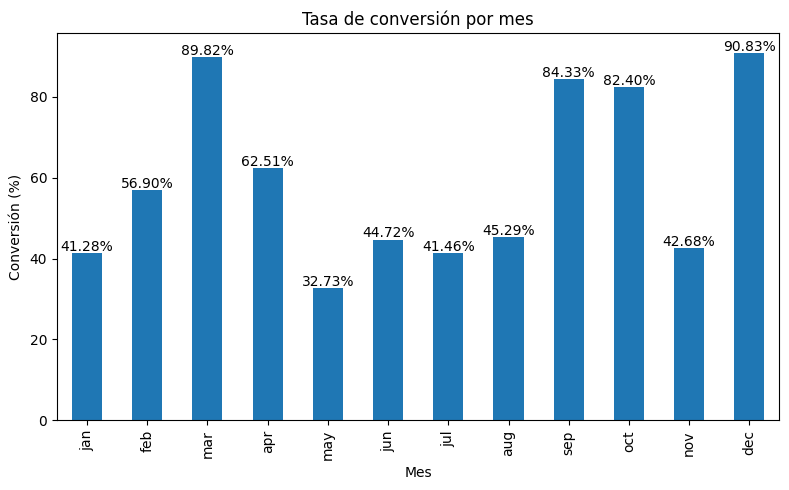

In [27]:

ax = conversion_month.plot(x="month", y="cr", kind="bar", figsize=(8, 5), legend=False)

plt.title("Tasa de conversión por mes")
plt.xlabel("Mes")
plt.ylabel("Conversión (%)")

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

ax.set_ylim(0, conversion_month["cr"].max() + 5)

plt.tight_layout()
plt.show()


### Dataframe de KPIs

In [29]:
kpi_data = {
    "KPI": [
        "Tasa de conversión global (%)",
        "Duración media llamadas (suscriptores)",
        "Porcentaje llamadas teléfono/móvil (%)",
        "Promedio contactos previos (suscriptores)",
        "Mes con mayor conversión",
        "Tasa de conversión del mejor mes (%)"
    ],
    "Valor": [
        round(conversion, 2),
        avg_duration_f,
        round(pct_calls, 2),
        round(avg_prev_contacts, 2),
        top_month,
        round(max_cr_valid, 2)
    ]
}

In [30]:

kpi_df = pd.DataFrame(kpi_data, index=range(1, len(kpi_data["KPI"]) + 1))
kpi_df

,KPI,Valor
1,Tasa de conversión global (%),47.38
2,Duración media llamadas (suscriptores),8 min 57 s
3,Porcentaje llamadas teléfono/móvil (%),76.98
4,Promedio contactos previos (suscriptores),1.17
5,Mes con mayor conversión,oct
6,Tasa de conversión del mejor mes (%),82.4


In [35]:
# KPI 5 ufficiale (sin MIN_N)

kpi_data = {
    "KPI": [
        "Tasa de conversión global (%)",
        "Duración media llamadas (suscriptores)",
        "Porcentaje llamadas teléfono/móvil (%)",
        "Promedio contactos previos (suscriptores)",
        "Mes con mayor conversión",
        "Tasa de conversión del mejor mes (%)"
    ],
    "Valor": [
        round(conversion, 2),
        avg_duration_f,
        round(pct_calls, 2),
        round(avg_prev_contacts, 2),
        top_month,   # dec
        top_cr       # 90.83
    ]
}

kpi_df = pd.DataFrame(kpi_data, index=range(1, len(kpi_data["KPI"]) + 1))
kpi_df


,KPI,Valor
1,Tasa de conversión global (%),47.38
2,Duración media llamadas (suscriptores),8 min 57 s
3,Porcentaje llamadas teléfono/móvil (%),76.98
4,Promedio contactos previos (suscriptores),1.17
5,Mes con mayor conversión,dec
6,Tasa de conversión del mejor mes (%),90.83


### 1. Comparacion con datos previos 

#### Outcome KPI
1. **Tasa de conversión global**

- Semana 1 49.7%  
- Semana 2 48.14%
- Semana 3: 47.38%

- mean = 48.40

El valor ha disminuido progresivamente respecto a la primera semana.

El desempeño habitual del CR se sitúa entre el primer y tercer cuartil (42.38% – 82.88%) y el valor actual (47.38%) se mantiene dentro de este rango, lo que define un comportamiento operativo estable del indicador.

#### Control / Stability metrics
1. **Duración media llamadas (suscriptores)**

- Semana 1 8:57 
- Semana 2 8:57
- Semana 3: 8:57

sin cambios 

2. **% llamadas teléfono / móvil**

- Semana 1 77.26% 
- Semana 2 77.07%
- Semana 3: 76.98% 

El valor muestra una ligera disminución acumulada, sin variaciones significativas, lo que sugiere estabilidad en la asignación de canales.

3. **Promedio contactos previos (suscriptores)**

- Semana 1 1.17
- Semana 2 1.17 
- Semana 3: 1.17

sin cambios 

#### Descriptive / Exploratory
1. **Mes con mayor conversión + Tasa de conversión del mejor mes (%)**

- Semana 1 December 91.74
- Semana 2 December 90.91 -> October 82.82 
- Semana 3: December 90.83%

Diciembre se mantiene como el mes con mayor tasa de conversión.

De forma exploratoria, se observa que octubre presenta una tasa de conversión elevada junto con un mayor volumen de clientes, situándose en el límite superior de la distribución del indicador.



### 2. Insights

1. La disminución observada en CR está dentro de la variabilidad normal del indicador y no indica una degradación en la efectividad de la campaña. 

2. La ausencia de cambios en las métricas operativas indica estabilidad del proceso y ausencia de cambios estructurales en el comportamiento del cliente. 

3. Diciembre se mantiene como el mes con mayor tasa de conversión según el KPI, mientras que octubre destaca a nivel descriptivo por una conversión elevada y un mayor volumen de clientes.


Los KPI se utilizan correctamente como una herramienta de seguimiento, no como un desencadenante de decisiones de emergencia.


A nivel descriptivo, octubre puede considerarse un punto de referencia para evaluar la eficacia de las campañas con un volumen de datos comparable.


La CR se apoya en:
- Duración moderada de las llamadas
- Número reducido de contactos
- Asignación correcta de canales

Esto indica un modelo de interacción con el cliente eficaz.

#### Propuestas

1. En esta etapa, es aconsejable utilizar el rango de normalidad CR en lugar de un valor objetivo fijo. 

2. Para evaluar el desempeño mensual, sólo se deben considerar los períodos con suficiente volumen de observación para evitar la distorsión de los indicadores.